In [16]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Geopackage data
gemeenten = gpd.read_file("data/wijken_en_gemeenten.gpkg", layer="gemeenten")
amsterdam_grens = gemeenten[gemeenten['gemeentenaam'] == 'Amsterdam']

wijken = gpd.read_file("data/wijken_en_gemeenten.gpkg", layer="wijken")
amsterdam_wijken = gpd.clip(wijken, amsterdam_grens)

# Crime data
df_crime = pd.read_csv("data/df_crime_average_per_year.csv")

amsterdam_crime = amsterdam_wijken.merge(
    df_crime,
    left_on='wijknaam',
    right_on='Wijk',
    how='left'
)

amsterdam_crime['Totaal misdrijven'] = amsterdam_crime['Totaal misdrijven'].fillna(0)

/Users/yoran/miniconda3/lib/python3.12/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 8 classes. Setting k to 7.
  self.bins = quantile(y, k=k)


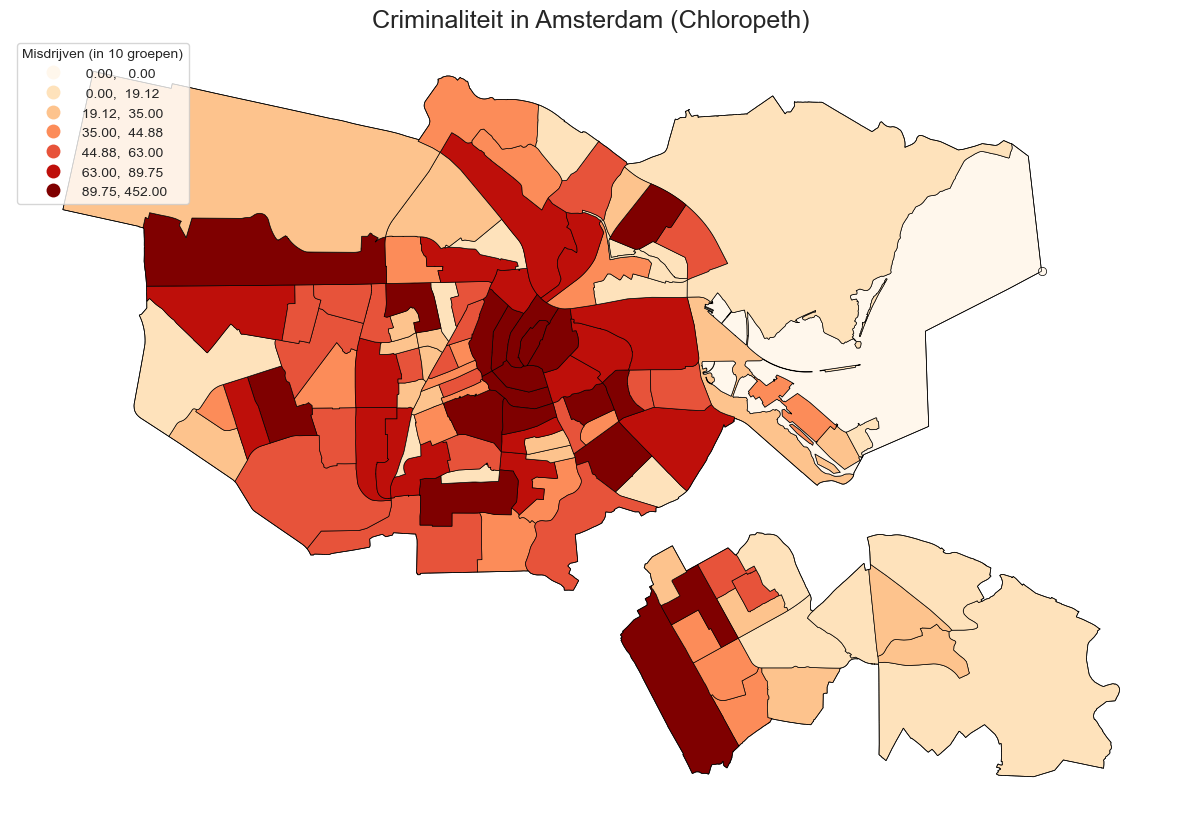

In [23]:
fig, ax = plt.subplots(figsize=(15, 12))

amsterdam_crime.plot(
    column='Totaal misdrijven',
    scheme='quantiles',
    k=8,
    cmap='OrRd',
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={'loc': 'upper left', 'title': "Misdrijven (in 10 groepen)"},
    ax=ax
)

ax.set_title("Criminaliteit in Amsterdam (Chloropeth)", fontsize=18)
ax.set_axis_off()

plt.show()